<a href="https://colab.research.google.com/github/Isabela-Tellez/BootcampIA/blob/main/05.%20Mayo-26/Sesgos_Dataset_Adult.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Tarea: ¿Son justos los datos? Analizando sesgos en el Adult Income Dataset


**Módulo II: Ética en IA — Sesgos en datasets**

---

## 🎯 ¿Qué vas a hacer en esta tarea?

En clase vimos cómo Amazon entrenó una IA con datos históricos sesgados... y la IA aprendió a discriminar.

En esta tarea vas a hacer exactamente lo que debería haber hecho el equipo de Amazon **antes** de entrenar: **auditar el dataset**.

Vas a explorar el **Adult Income Dataset**, un conjunto de datos del censo de EE.UU. de 1994, y responder a una pregunta clave:

> ### ❓ ¿El dataset trata igual a hombres y mujeres? ¿Y a personas de distintos orígenes?

---

## 📋 Instrucciones generales

- Las celdas con `# 👉 TU CÓDIGO AQUÍ` son las que debes completar.
- El resto del código ya está escrito — léelo, ejecútalo y entiéndelo.
- Al final hay **preguntas de reflexión** que debes responder en texto.
- **No hay respuestas incorrectas en la reflexión** — lo importante es que razonas.

---

## 📦 Sobre el dataset

El **Adult Income Dataset** (también llamado "Census Income") contiene datos de ~48.000 personas de EE.UU. en 1994. Cada fila es una persona, y la columna objetivo es:

- `income`: si esa persona gana **más de 50.000$ al año** (`>50K`) o **menos** (`<=50K`)

Las columnas incluyen: edad, nivel educativo, ocupación, horas de trabajo, género, etnia, país de origen...

> 💭 **Antes de empezar, piensa:** Si una IA aprende de este dataset para predecir quién merece un crédito o un ascenso, ¿qué podría salir mal?

---
## ⚙️ Parte 0 — Preparación: importar librerías y cargar datos

In [5]:
# Librerías necesarias — Ejecutar esta celda primero
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Configuración visual
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Paleta de colores
COLOR_PURPLE = '#4211BA'
COLOR_TEAL   = '#33C6CD'
COLOR_ORANGE = '#F97316'
COLOR_RED    = '#EF4444'
COLOR_GRAY   = '#94A3B8'

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [6]:
columnas = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race',
    'sex', 'capital_gain', 'capital_loss', 'hours_per_week',
    'native_country', 'income'
]

# Una sola lectura del archivo subido
df = pd.read_csv('adult.csv', names=columnas, skipinitialspace=True, header=0)

# Limpieza
df = df[df['occupation'] != '?']
df = df[df['workclass'] != '?']
df = df[df['native_country'] != '?']
df = df.reset_index(drop=True)

# Conversión de tipos
cols_numericas = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
df[cols_numericas] = df[cols_numericas].apply(pd.to_numeric, errors='coerce')

print(f'✅ Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas')
print(df.dtypes)

✅ Dataset cargado: 30162 filas, 15 columnas
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object


---
## 🔎 Parte 1 — Primera exploración: ¿Qué hay en el dataset?

Antes de buscar sesgos, necesitamos conocer los datos. Esto se llama **EDA (Exploratory Data Analysis)**.

In [7]:
# Primeras filas
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
1,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
2,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
3,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
4,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


In [8]:
# Información general del dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   fnlwgt          30162 non-null  int64 
 3   education       30162 non-null  object
 4   education_num   30162 non-null  int64 
 5   marital_status  30162 non-null  object
 6   occupation      30162 non-null  object
 7   relationship    30162 non-null  object
 8   race            30162 non-null  object
 9   sex             30162 non-null  object
 10  capital_gain    30162 non-null  int64 
 11  capital_loss    30162 non-null  int64 
 12  hours_per_week  30162 non-null  int64 
 13  native_country  30162 non-null  object
 14  income          30162 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.5+ MB


In [9]:
# Estadísticas descriptivas de las columnas numéricas
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,30162.000000,3.016200e+04,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1.897938e+05,10.121312,1092.007858,88.372489,40.931238
std,13.134665,1.056530e+05,2.549995,7406.346497,404.298370,11.979984
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.176272e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.784250e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376285e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### 📝 Ejercicio 1.1 — ¿Cuántas personas hay en el dataset?

Completa el código para mostrar:
- El número total de personas en el dataset
- Cuántas ganan `>50K` y cuántas `<=50K`

In [10]:
# Total de personas en el dataset
total = len(df)
print(f'Total de personas en el dataset: {total}')

# 👉 TU CÓDIGO AQUÍ
# Usar df['income'].value_counts() para ver cuántas personas hay en cada categoría de ingresos
conteo_ingresos = df['income'].value_counts()
print('\nDistribución de ingresos:')
print(conteo_ingresos)

Total de personas en el dataset: 30162

Distribución de ingresos:
income
<=50K    22654
>50K      7508
Name: count, dtype: int64


### 📝 Ejercicio 1.2 — ¿Cómo se distribuye el género en el dataset?

Vamos a ver cuántos hombres y mujeres hay, y qué porcentaje representan.

Distribución de género:
sex
Male      20380
Female     9782
Name: count, dtype: int64

En porcentaje:
sex
Male      67.6
Female    32.4
Name: proportion, dtype: float64


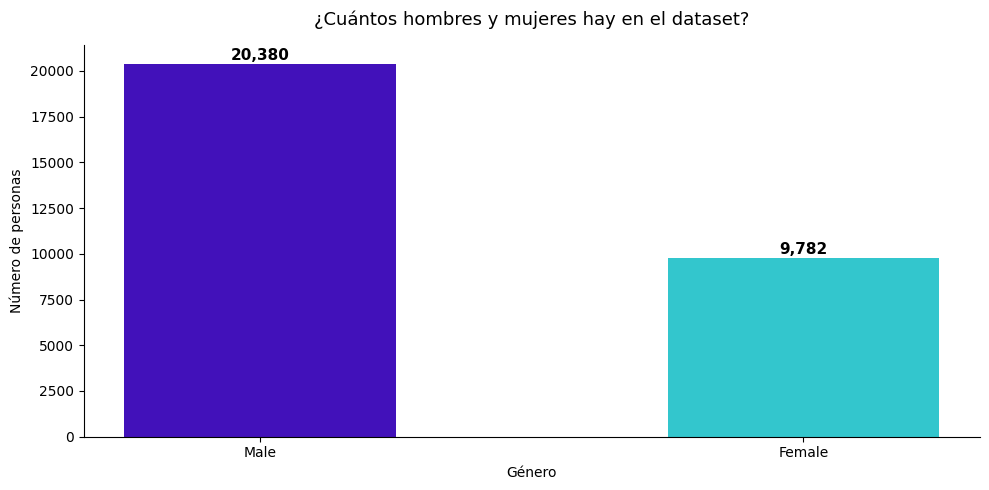


💬 ¿Ya ves algo sospechoso? Anótalo.


In [11]:
# Distribución de género
conteo_genero = df['sex'].value_counts()
porcentaje_genero = df['sex'].value_counts(normalize=True) * 100

print('Distribución de género:')
print(conteo_genero)
print('\nEn porcentaje:')

# 👉 TU CÓDIGO AQUÍ
# Imprimir porcentaje_genero redondeando a 1 decimal
# Pista: usa .round(1)
print(porcentaje_genero.round(1))

# Visualización — ya está hecho, solo ejecútalo
fig, ax = plt.subplots()
bars = ax.bar(conteo_genero.index, conteo_genero.values,
              color=[COLOR_PURPLE, COLOR_TEAL], width=0.5)
for bar, val in zip(bars, conteo_genero.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('¿Cuántos hombres y mujeres hay en el dataset?', fontsize=13, pad=15)
ax.set_ylabel('Número de personas')
ax.set_xlabel('Género')
plt.tight_layout()
plt.show()

print('\n💬 ¿Ya ves algo sospechoso? Anótalo.')

Analizando esos números: 67.6% hombres frente a 32.4% mujeres, es una diferencia bastante significativa (casi el doble de hombres que de mujeres);en ciencia de datos, cuando una categoría es mucho más frecuente que otra, los modelos tienden a "aprender" mucho mejor sobre la clase mayoritaria y a ignorar los patrones de la minoritaria.

---
## 🚨 Parte 2 — Análisis de sesgo por género

> **Pregunta clave:** ¿Qué porcentaje de hombres gana >50K vs. qué porcentaje de mujeres?

Si los porcentajes son muy distintos, se tiene una señal de sesgo de género en los datos.

### 📝 Ejercicio 2.1 — Porcentaje de ingresos altos por género

In [12]:
# Cálculo del porcentaje de personas con >50K por género
# groupby agrupa por género, luego se calcula la media de si income es >50K

# Primero se crea una columna binaria: 1 si gana >50K, 0 si no
df['income_alto'] = (df['income'] == '>50K').astype(int)

# 👉 TU CÓDIGO AQUÍ
# Agrupar df por 'sex' y calcular la media de 'income_alto'
# Multiplica por 100 para obtener el porcentaje
# Pista: df.groupby('sex')['income_alto'].mean() * 100
pct_por_genero = df.groupby('sex')['income_alto'].mean() * 100

print('Porcentaje de personas que ganan >50K, por género:')
print(pct_por_genero.round(1))

Porcentaje de personas que ganan >50K, por género:
sex
Female    11.4
Male      31.4
Name: income_alto, dtype: float64


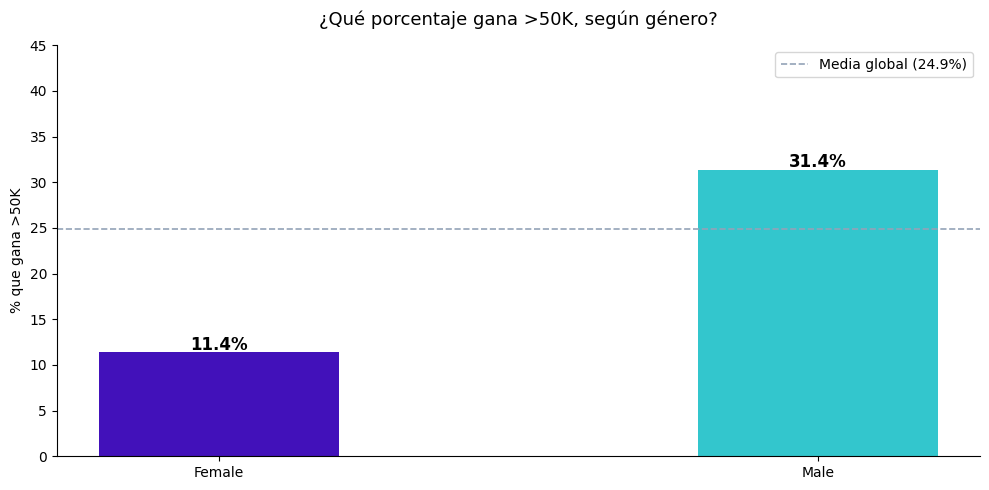

In [13]:
# Visualización del resultado
fig, ax = plt.subplots()
colores = [COLOR_PURPLE, COLOR_TEAL]
bars = ax.bar(pct_por_genero.index, pct_por_genero.values, color=colores, width=0.4)

for bar, val in zip(bars, pct_por_genero.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_title('¿Qué porcentaje gana >50K, según género?', fontsize=13, pad=15)
ax.set_ylabel('% que gana >50K')
ax.set_ylim(0, 45)
ax.axhline(y=df['income_alto'].mean()*100, color=COLOR_GRAY, linestyle='--',
           linewidth=1.2, label=f'Media global ({df["income_alto"].mean()*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.show()

### 📝 Ejercicio 2.2 — ¿Cuántas veces más probable es que un hombre gane >50K que una mujer?

In [14]:
pct_hombre = pct_por_genero['Male']
pct_mujer  = pct_por_genero['Female']

# 👉 TU CÓDIGO AQUÍ
# Calcula cuántas veces mayor es pct_hombre respecto a pct_mujer

ratio = pct_hombre / pct_mujer

print(f'Un hombre tiene {ratio:.1f}x más probabilidades de ganar >50K que una mujer.')
print(f'\nHombres con >50K: {pct_hombre:.1f}%')
print(f'Mujeres con >50K:  {pct_mujer:.1f}%')

Un hombre tiene 2.8x más probabilidades de ganar >50K que una mujer.

Hombres con >50K: 31.4%
Mujeres con >50K:  11.4%


### 📝 Ejercicio 2.3 — ¿Es solo por las horas de trabajo?

Una explicación posible es que los hombres trabajen más horas. Vamos a comprobarlo.

In [15]:
# Media de horas semanales por género
horas_genero = df.groupby('sex')['hours_per_week'].mean()
print('Media de horas semanales por género:')
print(horas_genero.round(1))

# 👉 TU CÓDIGO AQUÍ
# Calcula también la media de años de educación (columna 'education_num') por género
# Pista: igual que el código de arriba pero con 'education_num'
educ_genero = df.groupby('sex')['education_num'].mean()
print('\nMedia de años de educación por género:')
print(educ_genero.round(1))

print('\n💬 ¿Justifican las horas de trabajo o la educación la diferencia de ingresos?')

Media de horas semanales por género:
sex
Female    36.9
Male      42.9
Name: hours_per_week, dtype: float64

Media de años de educación por género:
sex
Female    10.1
Male      10.1
Name: education_num, dtype: float64

💬 ¿Justifican las horas de trabajo o la educación la diferencia de ingresos?


La educación no explica la brecha dado que el promedio de educación es idéntico, ain embargo Las horas semanales muestran una diferencia, lo cual explica parte de la disparidad, aunque una diferencia de ~6 horas semanales resulte en que un hombre tenga muchas más probabilidades de superar los 50K de ingresos no tiene sentido alguno.

---
## 🚨 Parte 3 — Análisis de sesgo por etnia

> **Pregunta clave:** ¿Varía la proporción de ingresos altos según la etnia?

Primero, veamos qué tipo de población o etnia hay en el dataset.

In [16]:
# Distribución de etnias en el dataset
conteo_etnia = df['race'].value_counts()
print('Distribución de etnias en el dataset:')
print(conteo_etnia)
print(f'\n⚠️  ¿Ves algún problema de representación?')

Distribución de etnias en el dataset:
race
White                 25933
Black                  2817
Asian-Pac-Islander      895
Amer-Indian-Eskimo      286
Other                   231
Name: count, dtype: int64

⚠️  ¿Ves algún problema de representación?


### 📝 Ejercicio 3.1 — Porcentaje de ingresos altos por etnias

In [17]:
# 👉 TU CÓDIGO AQUÍ
# Calcular el porcentaje de personas con >50K por etnias
# Es igual que en el ejercicio 2.1 pero agrupando por 'race'
pct_por_etnia = df.groupby('race')['income_alto'].mean() * 100
pct_por_etnia = pct_por_etnia.sort_values(ascending=False)

print('Porcentaje de personas que ganan >50K, por raza:')
print(pct_por_etnia.round(1))

Porcentaje de personas que ganan >50K, por raza:
race
Asian-Pac-Islander    27.7
White                 26.4
Black                 13.0
Amer-Indian-Eskimo    11.9
Other                  9.1
Name: income_alto, dtype: float64


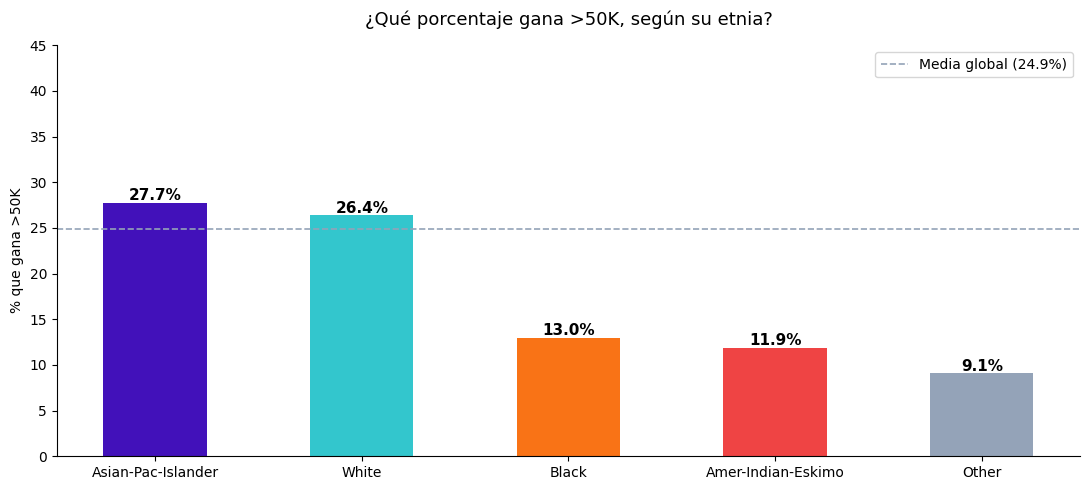

In [18]:
# Visualización
fig, ax = plt.subplots(figsize=(11, 5))
colores_etnia = [COLOR_PURPLE, COLOR_TEAL, COLOR_ORANGE, COLOR_RED, COLOR_GRAY]
bars = ax.bar(pct_por_etnia.index, pct_por_etnia.values,
              color=colores_etnia[:len(pct_por_etnia)], width=0.5)

for bar, val in zip(bars, pct_por_etnia.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_title('¿Qué porcentaje gana >50K, según su etnia?', fontsize=13, pad=15)
ax.set_ylabel('% que gana >50K')
ax.set_ylim(0, 45)
ax.axhline(y=df['income_alto'].mean()*100, color=COLOR_GRAY, linestyle='--',
           linewidth=1.2, label=f'Media global ({df["income_alto"].mean()*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.show()

### 📝 Ejercicio 3.2 — Combinando género y etnia

¿Qué pasa cuando cruzamos las dos variables? ¿Hay grupos especialmente perjudicados?

In [19]:
# Tabla cruzada: % de >50K por raza Y género
tabla_cruzada = df.groupby(['race', 'sex'])['income_alto'].mean() * 100
tabla_cruzada = tabla_cruzada.unstack(level='sex').round(1)

print('% de personas con ingresos >50K, por raza y género:')
print(tabla_cruzada)

# 👉 TU CÓDIGO AQUÍ
# Buscar cuál es el grupo con MENOR porcentaje de ingresos altos
# Pista: Usar tabla_cruzada.min() para encontrar el valor mínimo de cada columna
# o tabla_cruzada.stack().idxmin() para encontrar el índice (raza, sexo) con el mínimo
grupo_mas_perjudicado = tabla_cruzada.stack().idxmin()
valor_minimo = tabla_cruzada.stack().min()  # tabla_cruzada.stack().min()

print(f'\n🔴 Grupo con menor acceso a ingresos altos: {grupo_mas_perjudicado}')
print(f'   Solo el {valor_minimo:.1f}% de este grupo gana >50K')

% de personas con ingresos >50K, por raza y género:
sex                 Female  Male
race                            
Amer-Indian-Eskimo    10.3  12.8
Asian-Pac-Islander    13.9  34.4
Black                  6.1  19.8
Other                  4.6  11.8
White                 12.3  32.5

🔴 Grupo con menor acceso a ingresos altos: ('Other', 'Female')
   Solo el 4.6% de este grupo gana >50K


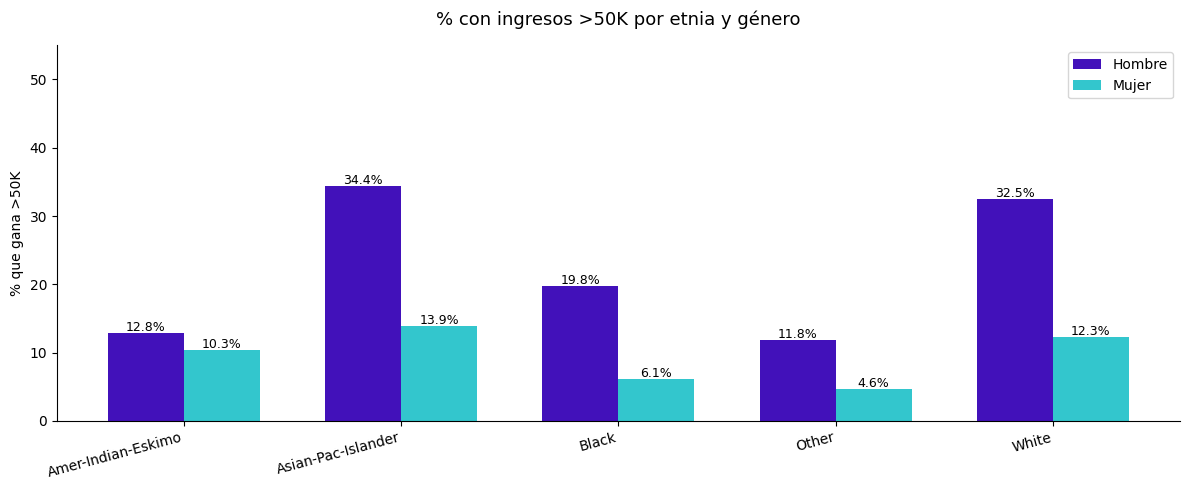

In [20]:
# Visualización de la tabla cruzada como gráfico de barras agrupadas
etnias = tabla_cruzada.index
x = range(len(etnias))
ancho = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars_m = ax.bar([i - ancho/2 for i in x], tabla_cruzada['Male'],
                width=ancho, label='Hombre', color=COLOR_PURPLE)
bars_f = ax.bar([i + ancho/2 for i in x], tabla_cruzada['Female'],
                width=ancho, label='Mujer', color=COLOR_TEAL)

for bar in bars_m:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)
for bar in bars_f:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(etnias, rotation=15, ha='right')
ax.set_title('% con ingresos >50K por etnia y género', fontsize=13, pad=15)
ax.set_ylabel('% que gana >50K')
ax.set_ylim(0, 55)
ax.legend()
plt.tight_layout()
plt.show()

---
## 🚨 Parte 4 — Análisis de representación

Un sesgo también puede venir de que ciertos grupos estén **infrarrepresentados** en el dataset.
Si hay muy pocos datos de un grupo, el modelo aprende muy poco sobre él y comete más errores.

### 📝 Ejercicio 4.1 — ¿Están todos los grupos igual de representados?

In [21]:
# Número de personas por raza (ya lo vimos antes)
conteo_etnia = df['race'].value_counts()
porcentaje_etnia = (conteo_etnia / len(df) * 100).round(1)

print('Representación de cada grupo racial en el dataset:')
for etnia, pct in porcentaje_etnia.items():
    barra = '█' * int(pct / 2)
    print(f'  {etnia:<30} {barra} {pct}%')

# 👉 TU CÓDIGO AQUÍ
# Calcular cuántas personas hay en el grupo menos representado
# Pista: Usar conteo_etnia.min() y conteo_etnia.idxmin()
grupo_menor = conteo_etnia.idxmin()
n_menor = conteo_etnia.min()

print(f'\n⚠️  El grupo menos representado es "{grupo_menor}" con solo {n_menor} personas.')
print(f'   Eso es solo el {n_menor/len(df)*100:.2f}% del dataset.')
print(f'\n💬 ¿Qué consecuencias tiene esto si entrenamos una IA con estos datos?')

Representación de cada grupo racial en el dataset:
  White                          ███████████████████████████████████████████ 86.0%
  Black                          ████ 9.3%
  Asian-Pac-Islander             █ 3.0%
  Amer-Indian-Eskimo              0.9%
  Other                           0.8%

⚠️  El grupo menos representado es "Other" con solo 231 personas.
   Eso es solo el 0.77% del dataset.

💬 ¿Qué consecuencias tiene esto si entrenamos una IA con estos datos?


Tu respuesta aquí:

Entrenar una IA con datos tan desbalanceados genera un sesgo de representación que invalida la equidad del modelo. Al ser minoritarios, el algoritmo aprende los patrones del grupo mayoritario, lo que causa que sus predicciones sean significativamente menos precisas y más discriminatorias para las minorías.


### 📝 Ejercicio 4.2 — Distribución de ocupaciones por género

¿Están hombres y mujeres concentrados en distintos tipos de trabajo?

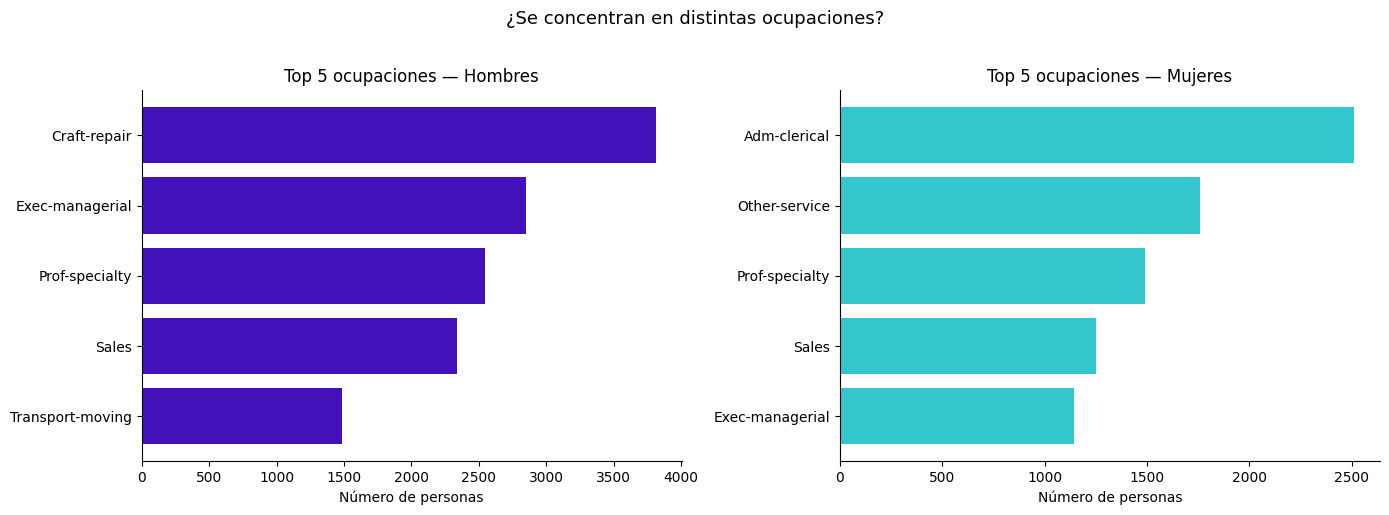

In [22]:
# Top 5 ocupaciones para hombres
top_ocu_hombre = df[df['sex'] == 'Male']['occupation'].value_counts().head(5)

# 👉 TU CÓDIGO AQUÍ
# Calcular el top 5 ocupaciones para mujeres
# Pista: Igual que arriba pero filtrando por 'Female'
top_ocu_mujer = df[df['sex'] == 'Female']['occupation'].value_counts().head(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(top_ocu_hombre.index[::-1], top_ocu_hombre.values[::-1], color=COLOR_PURPLE)
ax1.set_title('Top 5 ocupaciones — Hombres', fontsize=12)
ax1.set_xlabel('Número de personas')

ax2.barh(top_ocu_mujer.index[::-1], top_ocu_mujer.values[::-1], color=COLOR_TEAL)
ax2.set_title('Top 5 ocupaciones — Mujeres', fontsize=12)
ax2.set_xlabel('Número de personas')

plt.suptitle('¿Se concentran en distintas ocupaciones?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 🧩 Parte 5 — Resumen visual: el "mapa de sesgo"

Se va a crear un resumen visual de todos los hallazgos en un solo gráfico.

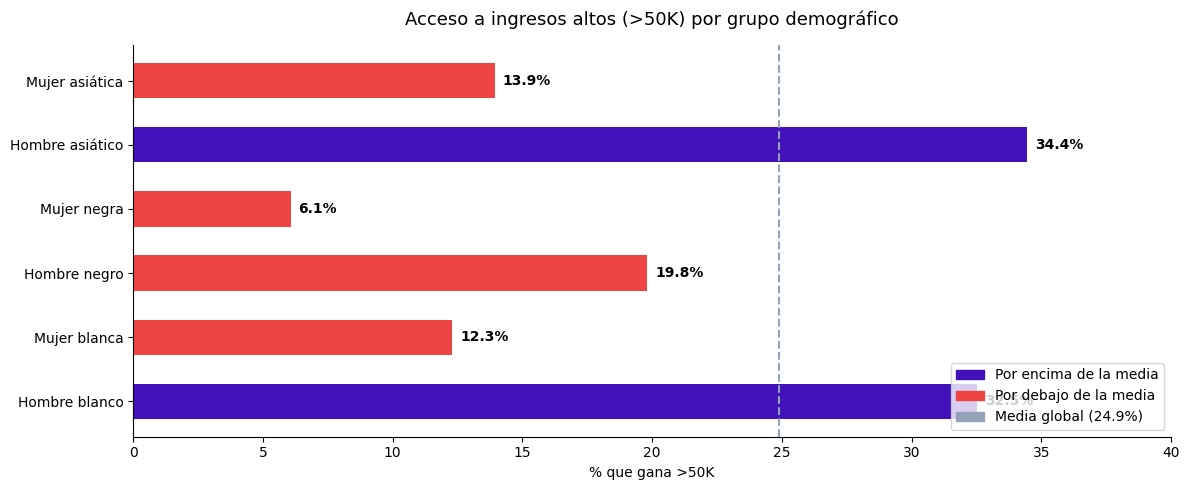

In [23]:
# Resumen: % de >50K por los principales grupos
grupos = {
    'Hombre blanco':          df[(df['sex']=='Male')   & (df['race']=='White')]['income_alto'].mean() * 100,
    'Mujer blanca':           df[(df['sex']=='Female') & (df['race']=='White')]['income_alto'].mean() * 100,
    'Hombre negro':           df[(df['sex']=='Male')   & (df['race']=='Black')]['income_alto'].mean() * 100,
    'Mujer negra':            df[(df['sex']=='Female') & (df['race']=='Black')]['income_alto'].mean() * 100,
    'Hombre asiático':        df[(df['sex']=='Male')   & (df['race']=='Asian-Pac-Islander')]['income_alto'].mean() * 100,
    'Mujer asiática':         df[(df['sex']=='Female') & (df['race']=='Asian-Pac-Islander')]['income_alto'].mean() * 100,
}

nombres = list(grupos.keys())
valores = list(grupos.values())
media_global = df['income_alto'].mean() * 100

colores_resumen = [COLOR_PURPLE if v >= media_global else COLOR_RED for v in valores]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(nombres, valores, color=colores_resumen, height=0.55)

for bar, val in zip(bars, valores):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.axvline(x=media_global, color=COLOR_GRAY, linestyle='--',
           linewidth=1.5, label=f'Media global ({media_global:.1f}%)')
ax.set_title('Acceso a ingresos altos (>50K) por grupo demográfico', fontsize=13, pad=15)
ax.set_xlabel('% que gana >50K')
ax.set_xlim(0, 40)

morado = mpatches.Patch(color=COLOR_PURPLE, label='Por encima de la media')
rojo   = mpatches.Patch(color=COLOR_RED,    label='Por debajo de la media')
linea  = mpatches.Patch(color=COLOR_GRAY,   label=f'Media global ({media_global:.1f}%)')
ax.legend(handles=[morado, rojo, linea], loc='lower right')

plt.tight_layout()
plt.show()

---
## 💬 Parte 6 — Reflexión final (obligatorio)

Esta es la parte más importante de la tarea. No hay respuestas correctas o incorrectas — lo que importa es que razonar y sacar conclusiones con lo visto.

**Responder en la celda de texto siguiente a estas 4 preguntas:**

### ✏️ Escribe aquí tus respuestas:

---

**Pregunta 1 — ¿Qué sesgo has encontrado?**  
Describe en 2-3 frases el sesgo de género y/o racial que has detectado en los datos.

*Tu respuesta:*

He detectado una brecha salarial de género persistente a pesar de una educación idéntica, junto a una fuerte subrepresentación de grupos raciales minoritarios que impide un análisis equitativo.
---

**Pregunta 2 — ¿De dónde viene este sesgo?**  
¿Crees que es un sesgo de representación, histórico, o ambos? ¿Por qué?

*Tu respuesta:*

Es una combinación de sesgo de representación (pocas muestras de minorías) y sesgo histórico (desigualdades estructurales y segregación ocupacional presentes en la sociedad que el dataset simplemente replica).
---

**Pregunta 3 — ¿Qué pasaría si entrenamos una IA con estos datos?**  
Si usamos este dataset para entrenar un modelo que predice si alguien merece un crédito bancario, ¿qué grupos se verían perjudicados? ¿Por qué?

*Tu respuesta:*

La IA discriminaría a mujeres y minorías raciales. Al aprender de un dataset desbalanceado, el modelo interiorizaría la desigualdad histórica como un "patrón de éxito", denegando injustamente créditos a quienes no encajan en el perfil del grupo mayoritario.
---

**Pregunta 4 — ¿Cómo lo arreglarías?**  
Propón al menos UNA acción concreta para reducir el sesgo antes de entrenar un modelo con estos datos.

*Tu respuesta:*

Realizaría un sobremuestreo (oversampling) de las clases minoritarias para equilibrar la muestra y aplicaría técnicas de entrenamiento consciente de la equidad (fairness-aware learning) para eliminar sesgos en las decisiones del modelo.
---

---
## 🏆 Bonus — Para quien quiera ir más lejos

*(Opcional para aprender más)*

/tmp/ipykernel_12319/3226481239.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  porcentaje_edad = df.groupby('age_group')['income_alto'].mean() * 100


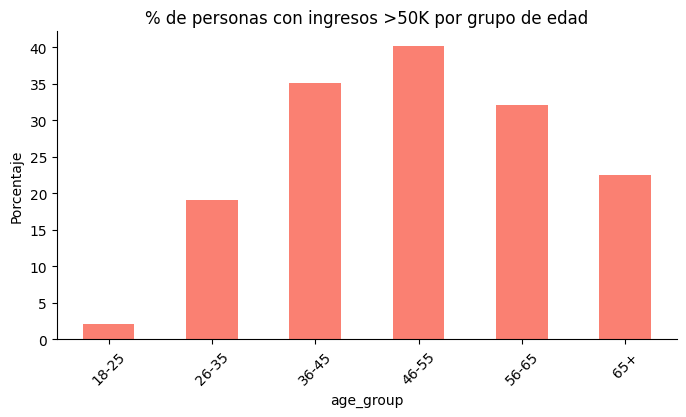

In [24]:
# BONUS 1 — Analiza el sesgo por edad
# ¿Hay grupos de edad con menos representación o peor acceso a ingresos altos?

# Crea grupos de edad con pd.cut()
df['age_group'] = pd.cut(df['age'], bins=[17, 25, 35, 45, 55, 65, 100],
                         labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

# 👉 TU CÓDIGO AQUÍ — calcula el % de >50K por grupo de edad y visualízalo

# 1. Agrupar por edad y calcular el porcentaje de ingresos altos
porcentaje_edad = df.groupby('age_group')['income_alto'].mean() * 100

# 2. Visualización rápida con un gráfico de barras
import matplotlib.pyplot as plt

porcentaje_edad.plot(kind='bar', color='salmon', figsize=(8, 4))
plt.title('% de personas con ingresos >50K por grupo de edad')
plt.ylabel('Porcentaje')
plt.xticks(rotation=45)
plt.show()

In [29]:
# BONUS 2 — ¿Qué país de origen tiene más acceso a ingresos altos?
# Filtra solo los países con más de 100 personas para que sea estadísticamente relevante

# 👉 TU CÓDIGO AQUÍ

# 1. Identificar países con más de 100 personas (usando el nombre correcto de la columna)
conteo_paises = df['native_country'].value_counts()
paises_relevantes = conteo_paises[conteo_paises > 100].index

# 2. Filtrar el DataFrame y calcular el % de >50K
df_filtrado = df[df['native_country'].isin(paises_relevantes)]
top_paises = df_filtrado.groupby('native_country')['income_alto'].mean() * 100

# 3. Ordenar y mostrar resultados
top_paises = top_paises.sort_values(ascending=False)
print('Porcentaje de ingresos >50K por país (países con >100 registros):')
print(top_paises.round(1))

Porcentaje de ingresos >50K por país (países con >100 registros):
native_country
Germany          34.4
Canada           33.6
Philippines      31.9
United-States    25.4
Puerto-Rico      11.0
Mexico            5.4
Name: income_alto, dtype: float64
